# Project 59 — Phase 3
## Proper GSEA and Per-Lineage Analysis

**Mentor:** Marouen Ben Guebila (Dana-Farber / Harvard)  
**Fellow:** Mateenah Jahan (Fatima Fellowship 2026)  
**Date started:** June 2026

---

### Background

In Phase 2, I classified 50 drugs using Fisher's exact test. The result was:
- 49 drugs = Category C (no signal)
- 1 drug = Category A (AS-605240, Liver) — but suspicious (only 2 strong genes)
- 0 drugs = Category B

### Problem with Phase 2

I mixed all the cell lines together (lung + brain + skin + liver) in one M vs F test.
This is called "pooled analysis". Because of this mixing, a real signal in one
tissue (like lung) got hidden by the noise from other tissues. That is why 49
out of 50 drugs came out as Category C.

### Goal of Phase 3

Follow Marouen's original recommendation properly:

**1. Per-lineage DE analysis**
Run male vs female test for each cell lineage SEPARATELY.
Lung cells alone. Brain cells alone. Liver cells alone.
Not all mixed together.

**2. Proper GSEA (not Fisher's)**
Use the `gseapy.prerank()` function. GSEA looks at the full ranked gene list.
Fisher's only looks at "in or out". GSEA is a stronger and more accurate test.

**3. Re-classify drugs into A, B, C**
With cleaner per-lineage signal, the classification will be more honest.

---

### Inputs (from Phase 2 — already downloaded)

- `signif.sbgenes.txt` — GTEx sex-biased genes per tissue (44 tissues, 13,294 genes)
- `level5_beta_trt_cp_n720216x12328.gctx` — CMAP expression matrix (33 GB)
- `siginfo_beta.txt` — CMAP experiment metadata
- `cellinfo_beta.txt` — CMAP cell line metadata
- `geneinfo_beta.txt` — Entrez to Ensembl ID translator
- Top 50 most-tested drugs list

### Expected outputs

- `top50_drug_classification_phase3.csv` — updated A/B/C labels
- GSEA NES (enrichment score) and FDR for each drug × tissue
- Verify if AS-605240's "Cat A" hit was a real signal or an artifact

In [2]:
# Install gseapy — proper GSEA library
!pip install gseapy --quiet

# Confirm it installed
import gseapy
print("gseapy version:", gseapy.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 9.6 MB/s eta 0:00:00
gseapy version: 1.2.1


## Step 2: Mount Google Drive

Colab is a temporary workspace. When the session ends, all files are deleted.
Google Drive is permanent storage that lives outside the Colab session.

We mount Drive so we can:
1. Load Phase 2 backup files (top50 results, csvs) without re-running everything
2. Save Phase 3 outputs permanently
3. Share results easily

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Confirm Drive is connected
import os
drive_files = os.listdir('/content/drive/MyDrive')
print(f"Drive mounted. Total items in MyDrive: {len(drive_files)}")
print("\nLooking for Phase 2 backup files...")

phase2_files = [
    'top50_drug_classification.csv',
    'top50_drugs_strong_de.png',
    'vorinostat_tissue_enrichment.csv',
    'vorinostat_tissue_enrichment.png'
]

for f in phase2_files:
    path = f'/content/drive/MyDrive/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✓ {f} found ({size:.1f} KB)")
    else:
        print(f"  ✗ {f} NOT found")

Mounted at /content/drive
Drive mounted. Total items in MyDrive: 473

Looking for Phase 2 backup files...
  ✓ top50_drug_classification.csv found (11.7 KB)
  ✓ top50_drugs_strong_de.png found (157.6 KB)
  ✓ vorinostat_tissue_enrichment.csv found (3.3 KB)
  ✓ vorinostat_tissue_enrichment.png found (225.9 KB)


## Step 3: Import libraries

All libraries are loaded here in one place. This makes the notebook clean —
we don't import inside every cell later.

Libraries we need:
- `pandas`, `numpy` — table and array handling
- `gseapy` — GSEA enrichment test (the new method)
- `scipy.stats` — Mann-Whitney U test (for per-gene M vs F)
- `statsmodels` — FDR correction
- `cmapPy` — reads the big CMAP gctx file
- `matplotlib` — for plots

In [4]:
# Data handling
import pandas as pd
import numpy as np
import os
import time

# Statistical tools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# GSEA — the proper method Marouen recommended
import gseapy

# CMAP file reader (need to install first)
!pip install cmapPy --quiet
from cmapPy.pandasGEXpress.parse import parse

# Plotting
import matplotlib.pyplot as plt

# Suppress warnings (clean output)
import warnings
warnings.filterwarnings('ignore')

# Confirm
print("✓ All libraries loaded")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  gseapy: {gseapy.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 4.0 MB/s eta 0:00:00
✓ All libraries loaded
  pandas: 2.2.2
  numpy: 2.0.2
  gseapy: 1.2.1


## Step 4: Download small metadata files

Phase 3 needs the same source files we used in Phase 2:
- **GTEx sbgenes** (31 MB) — sex-biased genes per tissue
- **CMAP cellinfo** (38 KB) — cell line info (lineage, donor sex)
- **CMAP geneinfo** (1.1 MB) — Entrez to Ensembl ID translator

The big files (siginfo 444 MB, gctx 33 GB) come in later steps.
We download small files first so the notebook starts fast.

Why redownload? Colab session is fresh — files we had in Phase 2 are gone.

In [5]:
# 1. CMAP cellinfo — cell line metadata (38 KB)
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/cellinfo_beta.txt

# 2. CMAP geneinfo — gene ID translator (1.1 MB)
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/geneinfo_beta.txt

# 3. GTEx sbgenes — sex-biased genes per tissue (31 MB)
# Note: GTEx URL is unreliable. Best to upload manually from Phase 2 backup.
# If the file is already on your Google Drive, we can copy it from there:

import shutil
import os

gtex_drive_path = '/content/drive/MyDrive/GTEx_Analysis_v8_sbgenes.tar.gz'
gtex_local_path = '/content/GTEx_Analysis_v8_sbgenes.tar.gz'

if os.path.exists(gtex_drive_path):
    shutil.copy(gtex_drive_path, gtex_local_path)
    print("✓ GTEx file copied from Drive")
else:
    print("✗ GTEx file not on Drive — please upload manually using files.upload()")
    print("  Or run: from google.colab import files; files.upload()")

# Confirm everything
print("\n--- Files ready ---")
!ls -lh cellinfo_beta.txt geneinfo_beta.txt GTEx_Analysis_v8_sbgenes.tar.gz 2>/dev/null

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 37979  100 37979    0     0   129k      0 --:--:-- --:--:-- --:--:--  129k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1114k  100 1114k    0     0  2644k      0 --:--:-- --:--:-- --:--:-- 2647k
✓ GTEx file copied from Drive

--- Files ready ---
-rw-r--r-- 1 root root  38K Jun  7 17:22 cellinfo_beta.txt
-rw-r--r-- 1 root root 1.1M Jun  7 17:22 geneinfo_beta.txt
-rw------- 1 root root  31M Jun  7 17:22 GTEx_Analysis_v8_sbgenes.tar.gz


## Step 4b: Upload GTEx file from computer

The GTEx file was not in Drive from before. So I will upload it manually
from my computer this one time. Then save it to Drive so future sessions
can load it directly.

In [6]:
# Upload GTEx file from your computer
from google.colab import files
print("Choose: GTEx_Analysis_v8_sbgenes.tar.gz from your computer")
uploaded = files.upload()

# Clean up the filename if it has (1), (2) etc.
import os
for fname in os.listdir('.'):
    if 'sbgenes' in fname and fname.endswith('.tar.gz'):
        if fname != 'GTEx_Analysis_v8_sbgenes.tar.gz':
            os.rename(fname, 'GTEx_Analysis_v8_sbgenes.tar.gz')
            print(f"Renamed {fname} to clean name")

# Save to Drive for future sessions
import shutil
shutil.copy('GTEx_Analysis_v8_sbgenes.tar.gz',
            '/content/drive/MyDrive/GTEx_Analysis_v8_sbgenes.tar.gz')
print("✓ Saved to Drive — future sessions will load instantly")

# Confirm
!ls -lh GTEx_Analysis_v8_sbgenes.tar.gz

Choose: GTEx_Analysis_v8_sbgenes.tar.gz from your computer


Saving GTEx_Analysis_v8_sbgenes.tar.gz to GTEx_Analysis_v8_sbgenes.tar (1).gz
✓ Saved to Drive — future sessions will load instantly
-rw------- 1 root root 31M Jun  7 17:22 GTEx_Analysis_v8_sbgenes.tar.gz


## Step 5: Unzip GTEx file and load into pandas

The file is compressed (.tar.gz). We unzip it to get the real data file
inside: `signif.sbgenes.txt`.

Then we load it into a pandas DataFrame so we can work with it.

In [7]:
# Unzip the GTEx file
!tar -xzf GTEx_Analysis_v8_sbgenes.tar.gz

# See what files came out
print("Files in GTEx folder:")
!ls GTEx_Analysis_v8_sbgenes/

# Load the main file into pandas
sbg = pd.read_csv('GTEx_Analysis_v8_sbgenes/signif.sbgenes.txt', sep='\t')

# Basic info
print(f"\n--- Data loaded ---")
print(f"Shape: {sbg.shape}")
print(f"Columns: {list(sbg.columns)}")
print(f"Unique tissues: {sbg['tissue'].nunique()}")
print(f"Unique genes: {sbg['gene'].nunique()}")

# Show first 5 rows
print(f"\nFirst 5 rows:")
sbg.head()

Files in GTEx folder:
effect_size_se.tsv  extract.signif.sbgenes.R  README
effect_size.tsv     LFSR.tsv		      signif.sbgenes.txt

--- Data loaded ---
Shape: (104864, 5)
Columns: ['gene', 'tissue', 'effsize', 'effsize_se', 'lfsr']
Unique tissues: 44
Unique genes: 13294

First 5 rows:


,gene,tissue,effsize,effsize_se,lfsr
0,ENSG00000229807.10,Adipose_Subcutaneous,9.802124,0.071315,0.0
1,ENSG00000147050.14,Adipose_Subcutaneous,0.623656,0.012053,0.0
2,ENSG00000126012.11,Adipose_Subcutaneous,0.455892,0.010462,0.0
3,ENSG00000141449.14,Adipose_Subcutaneous,-1.378039,0.092807,0.0
4,ENSG00000214717.11,Adipose_Subcutaneous,-0.277546,0.016683,0.0


### What the columns mean

| Column | Meaning |
|--------|---------|
| `gene` | Gene ID in Ensembl format (ENSG...) — version number after the dot |
| `tissue` | Body part name (44 total) |
| `effsize` | Size of the sex difference. **Positive = more active in MALES.** **Negative = more active in FEMALES.** |
| `effsize_se` | Standard error of effsize. Smaller = more reliable estimate. |
| `lfsr` | Local False Sign Rate. **Lower = more reliable.** Range 0 to 1. |

### Threshold used by GTEx

A gene is called "sex-biased" if **`lfsr ≤ 0.05`** in that tissue.

This file (`signif.sbgenes.txt`) only contains rows that already pass this threshold.
So every row here is a real sex-biased gene + tissue pair.

### How to read effsize

- `effsize = +9.8` → very strong male bias (huge difference)
- `effsize = +0.5` → mild male bias
- `effsize = 0` → no bias
- `effsize = −0.5` → mild female bias
- `effsize = −3.0` → strong female bias

### Example from our data

| Row | Gene | Tissue | effsize | Meaning |
|-----|------|--------|---------|---------|
| 0 | ENSG00000229807 (XIST) | Adipose | +9.80 | very strongly male-biased in fat tissue |
| 3 | ENSG00000141449 | Adipose | −1.38 | moderately female-biased |

## Step 6: Build sb_library dictionary

Right now, the data is in a flat table with 104,864 rows. To use it for
GSEA, we need a fast lookup:

`tissue name` → `list of sex-biased genes in that tissue`

We will also clean the gene IDs. GTEx uses IDs like `ENSG00000229807.10`
(with a `.10` version at the end). CMAP uses the version-less form
`ENSG00000229807`. We remove the version to make them match.

In [8]:
# Step 1: Build dictionary — tissue → list of genes
sb_library = sbg.groupby('tissue')['gene'].apply(list).to_dict()

# Step 2: Clean gene IDs — remove version number (.10, .14, etc.)
sb_library_clean = {
    tissue: [g.split('.')[0] for g in genes]
    for tissue, genes in sb_library.items()
}

# Step 3: Convert lists to sets (faster for GSEA later)
sb_library_sets = {tissue: set(genes) for tissue, genes in sb_library_clean.items()}

# Confirm
print(f"Total tissues in library: {len(sb_library_sets)}")
print(f"\nSize of each tissue's sb-gene set (top 5):")
for tissue, gene_set in sorted(sb_library_sets.items(),
                                key=lambda x: -len(x[1]))[:5]:
    print(f"  {tissue}: {len(gene_set)} genes")

print(f"\nSize of each tissue's sb-gene set (bottom 5):")
for tissue, gene_set in sorted(sb_library_sets.items(),
                                key=lambda x: -len(x[1]))[-5:]:
    print(f"  {tissue}: {len(gene_set)} genes")

# Quick check — Lung
print(f"\nLung sb-genes: {len(sb_library_sets['Lung'])}")
print(f"First 3 gene IDs in Lung: {list(sb_library_sets['Lung'])[:3]}")

Total tissues in library: 44

Size of each tissue's sb-gene set (top 5):
  Skin_Sun_Exposed_Lower_leg: 4558 genes
  Artery_Coronary: 4440 genes
  Skin_Not_Sun_Exposed_Suprapubic: 4170 genes
  Artery_Aorta: 3742 genes
  Artery_Tibial: 3649 genes

Size of each tissue's sb-gene set (bottom 5):
  Brain_Cerebellar_Hemisphere: 1096 genes
  Adrenal_Gland: 1076 genes
  Brain_Cerebellum: 1006 genes
  Liver: 717 genes
  Cells_EBV.transformed_lymphocytes: 473 genes

Lung sb-genes: 2108
First 3 gene IDs in Lung: ['ENSG00000164088', 'ENSG00000198865', 'ENSG00000081842']


## Step 7: CMAP cell line info and tissue mapping

CMAP labels cell lines with names like `lung`, `liver`, `central_nervous_system`.
GTEx labels tissues with names like `Lung`, `Liver`, `Brain_Cortex`.

These are different naming systems. We build a translation dictionary so we
can match a drug's "home tissue" (from CMAP) to a GTEx tissue (for GSEA).

This is the same mapping we used in Phase 2 — Marouen approved it.

In [9]:
# Load CMAP cell line info
cell = pd.read_csv('cellinfo_beta.txt', sep='\t')

print(f"Total CMAP cell lines: {len(cell)}")
print(f"\nDistribution by lineage:")
print(cell['cell_lineage'].value_counts())

# Build CMAP lineage → GTEx tissue mapping
cmap_to_gtex = {
    'lung':                              ['Lung'],
    'breast':                            ['Breast_Mammary_Tissue'],
    'skin':                              ['Skin_Sun_Exposed_Lower_leg',
                                          'Skin_Not_Sun_Exposed_Suprapubic'],
    'liver':                             ['Liver'],
    'kidney':                            ['Kidney_Cortex'],
    'stomach':                           ['Stomach'],
    'pancreas':                          ['Pancreas'],
    'large_intestine':                   ['Colon_Sigmoid', 'Colon_Transverse'],
    'haematopoietic_and_lymphoid_tissue':['Whole_Blood', 'Spleen',
                                          'Cells_EBV.transformed_lymphocytes'],
    'central_nervous_system':            [t for t in sb_library_sets.keys()
                                          if t.startswith('Brain_')],
}

# Verify mapping
print(f"\n--- CMAP → GTEx mapping ---")
for cmap_name, gtex_list in cmap_to_gtex.items():
    print(f"  {cmap_name:35} → {len(gtex_list)} GTEx tissue(s)")

# Coverage check
mapped_lineages = list(cmap_to_gtex.keys())
n_mapped = cell[cell['cell_lineage'].isin(mapped_lineages)].shape[0]
n_known  = cell[cell['cell_lineage'] != 'unknown'].shape[0]
print(f"\nCoverage: {n_mapped} of {n_known} known-lineage cell lines "
      f"mapped ({100*n_mapped/n_known:.0f}%)")

Total CMAP cell lines: 240

Distribution by lineage:
cell_lineage
unknown                               82
lung                                  32
haematopoietic_and_lymphoid_tissue    21
large_intestine                       19
ovary                                 15
breast                                11
endometrium                            9
skin                                   9
central_nervous_system                 7
prostate                               6
urinary_tract                          5
kidney                                 4
bone                                   4
liver                                  4
soft_tissue                            4
stomach                                3
placenta                               1
autonomic_ganglia                      1
cervix                                 1
pancreas                               1
upper_aerodigestive_tract              1
Name: count, dtype: int64

--- CMAP → GTEx mapping ---
  lung            

## Step 8: Load gene info and build ID translator

CMAP uses Entrez gene IDs (numbers like 1000, 6315).
GTEx uses Ensembl gene IDs (strings like ENSG00000170558).

These are two different naming systems for the same genes. We need a
translator so we can compare them.

We use `geneinfo_beta.txt` from CMAP — it has both ID systems side by side
for every gene.

In [10]:
# Load gene info table
genes_info = pd.read_csv('geneinfo_beta.txt', sep='\t')

print(f"Total genes in CMAP: {len(genes_info)}")
print(f"Columns: {list(genes_info.columns)}")

# Show first 5 rows
print(f"\nFirst 5 rows:")
print(genes_info[['gene_id', 'gene_symbol', 'ensembl_id']].head())

# Check how many genes have an Ensembl ID
n_with_ensg = genes_info['ensembl_id'].notna().sum()
print(f"\nGenes with Ensembl ID: {n_with_ensg} of {len(genes_info)} "
      f"({100*n_with_ensg/len(genes_info):.0f}%)")

# Build Entrez → Ensembl translator dictionary
gid_to_ensg = dict(zip(genes_info['gene_id'].astype(str),
                        genes_info['ensembl_id']))

# Also build the universe of all Ensembl IDs (for GSEA later)
universe_ensg = set(genes_info['ensembl_id'].dropna().unique())
print(f"\nUniverse of unique Ensembl IDs: {len(universe_ensg)}")

# Quick test — translate gene_id 1000 (should give CDH2's Ensembl ID)
print(f"\nTest: gene_id 1000 → Ensembl: {gid_to_ensg['1000']}")
print(f"        gene_symbol = {genes_info.loc[genes_info['gene_id']==1000, 'gene_symbol'].values[0]}")

Total genes in CMAP: 12328
Columns: ['gene_id', 'gene_symbol', 'ensembl_id', 'gene_title', 'gene_type', 'src', 'feature_space']

First 5 rows:
   gene_id gene_symbol       ensembl_id
0      750    GAS8-AS1  ENSG00000221819
1     6315     ATXN8OS              NaN
2     7503        XIST  ENSG00000229807
3     8552        INE1  ENSG00000224975
4     9834      FAM30A  ENSG00000226777

Genes with Ensembl ID: 12277 of 12328 (100%)

Universe of unique Ensembl IDs: 12276

Test: gene_id 1000 → Ensembl: ENSG00000170558
        gene_symbol = CDH2


## Step 9: Download siginfo (drug experiment metadata)

`siginfo_beta.txt` is the master metadata file from CMAP. Each row describes
ONE drug experiment:
- which drug was used
- on which cell line
- donor sex
- timepoint, dose, etc.

It has 1.2 million rows and is 444 MB. Download takes about 15-30 seconds.

We need this to link drug names to specific experiment IDs (called `sig_id`)
so we can pull those experiments out of the big gctx file in the next step.

In [11]:
# Download siginfo from CMAP
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/siginfo_beta.txt

# Confirm
!ls -lh siginfo_beta.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  443M  100  443M    0     0  42.6M      0  0:00:10  0:00:10 --:--:-- 45.8M
-rw-r--r-- 1 root root 444M Jun  7 17:26 siginfo_beta.txt


## Step 10: Load siginfo, filter, and pick top 50 drugs

Three things in this step:

1. **Load** siginfo into pandas (~30 seconds for 1.2 million rows)
2. **Filter** to only drug treatment experiments (`trt_cp`) with known donor sex
3. **Pick top 50 drugs** with at least 5 male AND 5 female cell lines tested

These are the same top 50 drugs we used in Phase 2

In [12]:
# Load siginfo (will take ~20-40 seconds)
print("Loading siginfo... (be patient, 444 MB)")
sig = pd.read_csv('siginfo_beta.txt', sep='\t', low_memory=False)
print(f"Loaded: {sig.shape[0]:,} rows × {sig.shape[1]} columns")

# Add cell lineage and donor sex info
cell_small = cell[['cell_iname', 'donor_sex', 'cell_type', 'cell_lineage']]
sig = sig.merge(cell_small, on='cell_iname', how='left')

# Filter: keep only drug treatments with known donor sex
sig_known = sig[
    (sig['pert_type'] == 'trt_cp') &
    (sig['donor_sex'].isin(['M', 'F']))
].copy()

print(f"\nAfter filtering:")
print(f"  Total drug experiments with known sex: {len(sig_known):,}")
print(f"  Donor sex split:")
print(sig_known['donor_sex'].value_counts())
print(f"  Unique drugs: {sig_known['cmap_name'].nunique():,}")
print(f"  Unique cell lines: {sig_known['cell_iname'].nunique()}")

# Build summary: each drug × number of male/female cell lines
drug_summary = sig_known.pivot_table(
    index='cmap_name',
    columns='donor_sex',
    values='cell_iname',
    aggfunc='nunique',
    fill_value=0
)
drug_summary['total'] = drug_summary['F'] + drug_summary['M']

# Filter: keep drugs with at least 5 M AND 5 F cell lines
good_drugs = drug_summary[
    (drug_summary['M'] >= 5) & (drug_summary['F'] >= 5)
].sort_values('total', ascending=False)

print(f"\nDrugs with ≥5 M AND ≥5 F cell lines: {len(good_drugs):,}")

# Pick top 50 most-tested
top50_drugs = good_drugs.head(50)
top50_names = top50_drugs.index.tolist()

print(f"\nTop 10 drugs (most tested):")
print(top50_drugs.head(10).to_string())

Loading siginfo... (be patient, 444 MB)
Loaded: 1,201,944 rows × 37 columns

After filtering:
  Total drug experiments with known sex: 596,117
  Donor sex split:
donor_sex
F    341977
M    254140
Name: count, dtype: int64
  Unique drugs: 32,917
  Unique cell lines: 136

Drugs with ≥5 M AND ≥5 F cell lines: 2,408

Top 10 drugs (most tested):
donor_sex      F   M  total
cmap_name                  
selumetinib   65  52    117
vorinostat    63  53    116
tozasertib    65  51    116
NVP-BEZ235    64  50    114
fostamatinib  62  49    111
bortezomib    59  49    108
olaparib      60  47    107
BI-2536       60  47    107
ABT-737       60  46    106
troglitazone  57  48    105


From 1.2M raw rows, we filtered to 596K usable drug experiments → 2,408 drugs have balanced M+F testing → top 50 most-tested were picked for Phase 3 analysis.



## Step 11: Download the gctx file (33 GB)

This is the main CMAP data file — actual gene expression numbers for all
720,216 drug experiments. Without this we cannot run any DE test.

**Heads up:**
- File size: **33 GB**
- Download time: **~15 minutes** at normal Colab speed
- Saved location: `/content/` (Colab temporary storage)

We do NOT save this to Drive — too big for free Drive (15 GB limit).
If your session ends, you will need to re-download. So finish Phase 3
in one session if possible.

In [13]:
# Check if file already exists (in case we re-ran)
import os
gctx_file = 'level5_beta_trt_cp_n720216x12328.gctx'

if os.path.exists(gctx_file):
    size_gb = os.path.getsize(gctx_file) / 1e9
    print(f"✓ File already exists: {size_gb:.1f} GB")
else:
    print("Downloading gctx (33 GB) — this will take ~15 minutes...")
    print("Don't close the tab. You can do other things in another tab.")
    !curl -O https://cmapreg.s3.amazonaws.com/galenAI/level5_beta_trt_cp_n720216x12328.gctx

# Confirm
print("\n--- Final check ---")
!ls -lh level5_beta_trt_cp_n720216x12328.gctx

Don't close the tab. You can do other things in another tab.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 33.0G  100 33.0G    0     0  43.9M      0  0:12:49  0:12:49 --:--:-- 56.5M

--- Final check ---
-rw-r--r-- 1 root root 34G Jun  7 17:39 level5_beta_trt_cp_n720216x12328.gctx


## Step 12: Verify gctx file and prepare drug experiment IDs

The gctx file is 34 GB. We don't load the whole thing — too big for memory.

Instead we read only the **column labels** (the experiment IDs). This is
small and fast (~5 seconds).

Then we check: for each of our 50 drugs, do all its experiments exist
in the file? This catches missing data before we start the long analysis.

In [14]:
# Read ONLY column metadata (fast — does not load the full 34 GB)
gctx_file = 'level5_beta_trt_cp_n720216x12328.gctx'

print("Reading gctx column labels (fast)...")
col_meta = parse(gctx_file, col_meta_only=True)
gctx_sigs = set(col_meta.index)

print(f"Total signatures in gctx: {len(gctx_sigs):,}")

# Find experiments for our top 50 drugs
sig_for_top50 = sig_known[sig_known['cmap_name'].isin(top50_names)].copy()
print(f"\nTotal experiments for top 50 drugs (from siginfo): {len(sig_for_top50):,}")

# Check how many of those exist in the gctx file
valid_sigs = [s for s in sig_for_top50['sig_id'] if s in gctx_sigs]
print(f"Valid signatures present in gctx file: {len(valid_sigs):,}")
print(f"Coverage: {100*len(valid_sigs)/len(sig_for_top50):.1f}%")

# Per-drug count
print(f"\nExperiments per drug (top 10):")
drug_counts = sig_for_top50.groupby('cmap_name').size().sort_values(ascending=False)
print(drug_counts.head(10).to_string())

Reading gctx column labels (fast)...
Total signatures in gctx: 720,216

Total experiments for top 50 drugs (from siginfo): 36,523
Valid signatures present in gctx file: 36,523
Coverage: 100.0%

Experiments per drug (top 10):
cmap_name
bortezomib      7300
vorinostat      2641
mitoxantrone    1516
dasatinib       1098
afatinib         976
selumetinib      952
erlotinib        888
gefitinib        860
tozasertib       854
troglitazone     820


## Step 13: Per-lineage Differential Expression function

This is the main improvement over Phase 2.

**Phase 2 approach (pooled):**
For vorinostat, mix all lineages (lung + brain + skin + liver + ...)
in one M vs F test. Result: tissue-specific signal got diluted.

**Phase 3 approach (per-lineage):**
For vorinostat × lung: test only lung cells M vs F → get lung DE genes
For vorinostat × brain: test only brain cells M vs F → get brain DE genes
For vorinostat × skin: test only skin cells M vs F → get skin DE genes
And so on.

Each lineage gets its own clean signal. Then we compare each lineage's
DE genes to that tissue's GTEx sb-genes using GSEA.

This function does Step 1 — per-lineage DE only. GSEA comes next.

In [15]:
def per_lineage_DE(drug_name, lineage, min_per_group=5):
    """
    Run M vs F differential expression for ONE drug × ONE lineage.

    Args:
      drug_name: drug name (e.g., 'vorinostat')
      lineage: CMAP cell_lineage (e.g., 'lung')
      min_per_group: minimum cell lines needed in EACH of M and F (default 5)

    Returns:
      DataFrame with gene_id, gene_symbol, ensembl_id, difference, p_value, p_adj, score
      OR None if not enough samples in this lineage
    """
    # Step 1: Pick this drug × this lineage's experiments
    sigs = sig_known[
        (sig_known['cmap_name'] == drug_name) &
        (sig_known['cell_lineage'] == lineage)
    ]
    m_sigs = sigs[sigs['donor_sex'] == 'M']
    f_sigs = sigs[sigs['donor_sex'] == 'F']

    # Step 2: Check if enough samples
    n_m_cells = m_sigs['cell_iname'].nunique()
    n_f_cells = f_sigs['cell_iname'].nunique()
    if n_m_cells < min_per_group or n_f_cells < min_per_group:
        return None

    # Step 3: Pull only these experiments from gctx (small extract)
    all_ids = list(sigs['sig_id'])
    valid_ids = [s for s in all_ids if s in gctx_sigs]
    if len(valid_ids) < 20:
        return None

    drug_data = parse(gctx_file, cid=valid_ids)
    expr = drug_data.data_df  # 12,328 genes × N experiments

    # Step 4: Separate M vs F columns
    sex_map = sigs.set_index('sig_id')['donor_sex'].to_dict()
    m_cols = [s for s in expr.columns if sex_map.get(s) == 'M']
    f_cols = [s for s in expr.columns if sex_map.get(s) == 'F']

    if len(m_cols) < 10 or len(f_cols) < 10:
        return None  # too few experiments

    m_expr = expr[m_cols].values
    f_expr = expr[f_cols].values

    # Step 5: Mann-Whitney U test per gene
    p_vals, diffs = [], []
    for i in range(expr.shape[0]):
        try:
            _, p = mannwhitneyu(m_expr[i], f_expr[i], alternative='two-sided')
        except:
            p = 1.0
        p_vals.append(p)
        diffs.append(m_expr[i].mean() - f_expr[i].mean())

    # Step 6: Build results table
    de = pd.DataFrame({
        'gene_id': expr.index.astype(str),
        'difference': diffs,
        'p_value': p_vals
    })
    de['p_adj'] = multipletests(de['p_value'], method='fdr_bh')[1]

    # GSEA needs a ranked score: signed -log10(p)
    de['score'] = np.sign(de['difference']) * -np.log10(de['p_value'] + 1e-300)

    # Add Ensembl IDs + gene symbols
    de['ensembl_id'] = de['gene_id'].map(gid_to_ensg)
    de = de.merge(
        genes_info[['gene_id', 'gene_symbol']].astype({'gene_id': str}),
        on='gene_id', how='left'
    )

    return de.sort_values('score', ascending=False)


print("✓ per_lineage_DE function defined")
print("\nNow test on vorinostat × lung:")
result = per_lineage_DE('vorinostat', 'lung')
if result is None:
    print("  Not enough samples — skip")
else:
    print(f"  Lineage: lung")
    print(f"  Total genes: {len(result):,}")
    print(f"  Strong DE genes (p_adj<0.05 & |diff|>0.5): "
          f"{((result['p_adj']<0.05) & (result['difference'].abs()>0.5)).sum()}")
    print(f"\n  Top 5 male-biased genes (by score):")
    print(result.head(5)[['gene_symbol', 'difference', 'p_adj', 'score']].to_string(index=False))
    print(f"\n  Top 5 female-biased genes (by score):")
    print(result.tail(5)[['gene_symbol', 'difference', 'p_adj', 'score']].to_string(index=False))

✓ per_lineage_DE function defined

Now test on vorinostat × lung:
  Lineage: lung
  Total genes: 12,328
  Strong DE genes (p_adj<0.05 & |diff|>0.5): 1862

  Top 5 male-biased genes (by score):
gene_symbol  difference        p_adj     score
     TAPBPL    1.274361 2.735583e-22 25.224517
     JCHAIN    1.166380 1.210472e-18 20.966545
      QSOX1    1.341490 2.096281e-17 19.541154
     PRSS16    1.017777 4.982280e-17 19.031737
     MAPK13    3.066024 5.010105e-17 19.010835

  Top 5 female-biased genes (by score):
gene_symbol  difference        p_adj      score
       CTSL   -3.325344 4.294976e-20 -22.679781
       LRP4   -1.236757 4.704471e-21 -23.719412
      MYO10   -2.237872 3.103707e-21 -23.996952
     TXNRD1   -2.888725 2.735583e-22 -25.176722
    ST3GAL5   -4.576361 1.306832e-28 -31.974673


## Step 14: GSEA function using gseapy.prerank()

Phase 2 used Fisher's exact test — only checks binary "in or out" overlap.

Phase 3 uses GSEA — looks at the FULL RANKED list.

How GSEA works:
1. Take the ranked gene list (top = male-biased, bottom = female-biased)
2. Walk through the list top to bottom
3. Track when sb-genes appear
4. If sb-genes cluster near the top OR bottom → strong enrichment
5. If they scatter through middle → no enrichment

Output:
- NES (Normalized Enrichment Score) — strength and direction
- FDR (False Discovery Rate) — reliability after multiple-tissue correction

In [16]:
def run_gsea(de_results, gene_sets_dict, min_genes=15):
    """
    Run GSEA preranked on DE results against multiple gene sets.

    Args:
      de_results: DataFrame from per_lineage_DE() with 'ensembl_id' and 'score'
      gene_sets_dict: dict of {set_name: set of Ensembl IDs}
      min_genes: minimum genes a set needs (default 15, gseapy requires this)

    Returns:
      DataFrame with NES, FDR, lead genes per gene set
    """
    # Step 1: Build ranked list (sort by score, drop NaN)
    ranked = de_results.dropna(subset=['ensembl_id', 'score']).copy()
    ranked = ranked.drop_duplicates(subset='ensembl_id', keep='first')
    ranked = ranked.set_index('ensembl_id')['score'].sort_values(ascending=False)

    # Step 2: Convert sets to lists (gseapy expects lists)
    gene_sets_for_gsea = {
        name: list(genes & set(ranked.index))
        for name, genes in gene_sets_dict.items()
    }
    gene_sets_for_gsea = {
        name: genes for name, genes in gene_sets_for_gsea.items()
        if len(genes) >= min_genes
    }

    if not gene_sets_for_gsea:
        return pd.DataFrame()

    # Step 3: Run GSEA prerank
    pre_res = gseapy.prerank(
        rnk=ranked.reset_index(),
        gene_sets=gene_sets_for_gsea,
        outdir=None,           # don't save to disk
        permutation_num=1000,  # for FDR
        seed=42,
        verbose=False,
        no_plot=True,
        min_size=min_genes,
        max_size=10000
    )

    return pre_res.res2d


# Test on vorinostat × lung
print("Testing GSEA on vorinostat × lung result vs all 44 tissues...")
gsea_result = run_gsea(result, sb_library_sets)

print(f"\nTotal tissue results: {len(gsea_result)}")
print(f"\nTop 5 by NES:")
print(gsea_result.head(5)[['Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val']].to_string(index=False))

# Significant tissues (FDR < 0.05)
sig = gsea_result[gsea_result['FDR q-val'] < 0.05]
print(f"\nFDR-significant tissues (q<0.05): {len(sig)}")
if len(sig) > 0:
    print(sig[['Term', 'NES', 'FDR q-val']].to_string(index=False))

2026-06-07 17:39:46,393 [WARNING] Duplicated values found in preranked stats: 29.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Testing GSEA on vorinostat × lung result vs all 44 tissues...

Total tissue results: 44

Top 5 by NES:
                      Term        ES       NES  NOM p-val  FDR q-val
     Breast_Mammary_Tissue -0.373273 -1.431355   0.001000   0.001000
                     Liver -0.371635 -1.368551   0.001253   0.002113
Cells_Cultured_fibroblasts -0.340092 -1.335965   0.001000   0.002465
              Artery_Aorta -0.322757 -1.268267   0.001000   0.021390
           Muscle_Skeletal -0.316704 -1.239399   0.001000   0.034013

FDR-significant tissues (q<0.05): 5
                      Term       NES  FDR q-val
     Breast_Mammary_Tissue -1.431355   0.001000
                     Liver -1.368551   0.002113
Cells_Cultured_fibroblasts -1.335965   0.002465
              Artery_Aorta -1.268267   0.021390
           Muscle_Skeletal -1.239399   0.034013


## Step 15: Analyze one drug across all its lineages

This wraps everything together. For ONE drug, we:

1. List all lineages the drug was tested in (with ≥5 M and ≥5 F)
2. Run per-lineage DE for each
3. Run GSEA for each (vs all 44 tissues)
4. Combine results
5. Assign A/B/C category based on combined signal

Category rules:
- **A** = at least ONE lineage shows FDR-significant enrichment in its HOME tissue
- **B** = at least ONE lineage shows FDR-significant enrichment but in WRONG tissue
- **C** = no FDR-significant enrichment in any lineage

In [17]:
def analyze_drug_full(drug_name, verbose=True):
    """
    Full per-lineage analysis for one drug.
    Returns dict with per-lineage DE/GSEA results and final A/B/C category.
    """
    # Step 1: Find all eligible lineages for this drug
    drug_sigs = sig_known[sig_known['cmap_name'] == drug_name]
    drug_lineages = set(drug_sigs['cell_lineage'].dropna().unique()) - {'unknown'}

    if verbose:
        print(f"\n=== {drug_name} ===")
        print(f"Lineages drug was tested in: {len(drug_lineages)}")

    # Step 2: For each lineage with enough samples, run DE + GSEA
    lineage_results = {}
    for lineage in drug_lineages:
        de = per_lineage_DE(drug_name, lineage)
        if de is None:
            continue

        if verbose:
            n_strong = ((de['p_adj']<0.05) & (de['difference'].abs()>0.5)).sum()
            print(f"  Lineage '{lineage}': {n_strong} strong DE genes")

        # Run GSEA
        try:
            gsea = run_gsea(de, sb_library_sets)
        except Exception as e:
            if verbose:
                print(f"    GSEA error: {e}")
            continue

        lineage_results[lineage] = {
            'de': de,
            'gsea': gsea,
            'sig_tissues': gsea[gsea['FDR q-val'] < 0.05]['Term'].tolist()
        }

    # Step 3: Decide A/B/C based on COMBINED signal
    category = 'C'
    cat_a_evidence = []
    cat_b_evidence = []

    for lineage, res in lineage_results.items():
        sig_tissues = res['sig_tissues']
        if not sig_tissues:
            continue

        # Drug's home tissues for this lineage
        home_tissues = set(cmap_to_gtex.get(lineage, []))

        for t in sig_tissues:
            nes = res['gsea'][res['gsea']['Term']==t]['NES'].iloc[0]
            fdr = res['gsea'][res['gsea']['Term']==t]['FDR q-val'].iloc[0]
            if t in home_tissues:
                cat_a_evidence.append((lineage, t, nes, fdr))
            else:
                cat_b_evidence.append((lineage, t, nes, fdr))

    if cat_a_evidence:
        category = 'A'
    elif cat_b_evidence:
        category = 'B'

    if verbose:
        print(f"\nCategory: {category}")
        if cat_a_evidence:
            print(f"  Cat A evidence (lineage, tissue, NES, FDR):")
            for ev in cat_a_evidence[:5]:
                print(f"    {ev}")
        elif cat_b_evidence:
            print(f"  Cat B evidence (lineage, tissue, NES, FDR):")
            for ev in cat_b_evidence[:5]:
                print(f"    {ev}")

    return {
        'drug': drug_name,
        'category': category,
        'n_lineages_tested': len(lineage_results),
        'cat_a_evidence': cat_a_evidence,
        'cat_b_evidence': cat_b_evidence,
        'lineage_results': lineage_results
    }


# Test on vorinostat
print("Testing analyze_drug_full() on vorinostat...")
print("(Will take ~2-5 minutes for vorinostat — many lineages)")
import time
t0 = time.time()
vori_full = analyze_drug_full('vorinostat', verbose=True)
print(f"\nDone in {time.time()-t0:.0f} seconds")

Testing analyze_drug_full() on vorinostat...
(Will take ~2-5 minutes for vorinostat — many lineages)

=== vorinostat ===
Lineages drug was tested in: 20


2026-06-07 17:40:12,949 [WARNING] Duplicated values found in preranked stats: 78.91% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  Lineage 'large_intestine': 1011 strong DE genes


2026-06-07 17:40:40,651 [WARNING] Duplicated values found in preranked stats: 29.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  Lineage 'lung': 1862 strong DE genes


2026-06-07 17:41:07,238 [WARNING] Duplicated values found in preranked stats: 54.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  Lineage 'haematopoietic_and_lymphoid_tissue': 512 strong DE genes

Category: A
  Cat A evidence (lineage, tissue, NES, FDR):
    ('large_intestine', 'Colon_Transverse', -1.1893003595094547, np.float64(0.028884908195253023))

Done in 81 seconds


## Step 16: Run pipeline on all 50 drugs

Now we run the full Phase 3 pipeline on all 50 drugs.

Estimated time: **30-60 minutes** depending on how many lineages each drug
has. Vorinostat took 81 seconds — most drugs will be faster (fewer lineages).

We save a checkpoint every 5 drugs so progress is safe if the kernel crashes.

In [18]:
import time

all_results = []
start = time.time()

for i, drug_name in enumerate(top50_names, 1):
    t0 = time.time()

    try:
        res = analyze_drug_full(drug_name, verbose=False)
    except Exception as e:
        print(f"[{i:2}/50] {drug_name:30} → ERROR: {e}")
        continue

    elapsed = time.time() - t0

    # Summary line
    n_lin = res['n_lineages_tested']
    n_a = len(res['cat_a_evidence'])
    n_b = len(res['cat_b_evidence'])
    print(f"[{i:2}/50] {drug_name:30} → {elapsed:>4.0f}s · {n_lin} lineages · Cat {res['category']} · A_ev={n_a} B_ev={n_b}")

    # Save compact summary (drop heavy DE dataframes)
    summary = {
        'drug': res['drug'],
        'category': res['category'],
        'n_lineages_tested': res['n_lineages_tested'],
        'cat_a_evidence_count': n_a,
        'cat_b_evidence_count': n_b,
        'cat_a_top': res['cat_a_evidence'][:3] if res['cat_a_evidence'] else [],
        'cat_b_top': res['cat_b_evidence'][:3] if res['cat_b_evidence'] else [],
    }
    all_results.append(summary)

    # Checkpoint every 5 drugs
    if i % 5 == 0:
        df_chkpt = pd.DataFrame(all_results)
        df_chkpt.to_csv('phase3_classification_checkpoint.csv', index=False)
        print(f"  ↳ Checkpoint saved · Total elapsed: {(time.time()-start)/60:.1f} min")

# Final save
results_df = pd.DataFrame(all_results)
results_df.to_csv('phase3_classification_final.csv', index=False)

print(f"\n=== DONE === Total time: {(time.time()-start)/60:.1f} minutes")
print(f"\nCategory breakdown:")
print(results_df['category'].value_counts())

2026-06-07 17:41:32,428 [WARNING] Duplicated values found in preranked stats: 95.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-07 17:41:59,683 [WARNING] Duplicated values found in preranked stats: 83.11% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-07 17:42:25,409 [WARNING] Duplicated values found in preranked stats: 88.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[ 1/50] selumetinib                    →   78s · 3 lineages · Cat B · A_ev=0 B_ev=2


2026-06-07 17:42:52,205 [WARNING] Duplicated values found in preranked stats: 78.91% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-07 17:43:20,116 [WARNING] Duplicated values found in preranked stats: 29.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-07 17:43:45,514 [WARNING] Duplicated values found in preranked stats: 54.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[ 2/50] vorinostat                     →   80s · 3 lineages · Cat A · A_ev=1 B_ev=32


2026-06-07 17:44:11,501 [WARNING] Duplicated values found in preranked stats: 96.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-07 17:44:37,651 [WARNING] Duplicated values found in preranked stats: 80.14% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-07 17:45:02,585 [WARNING] Duplicated values found in preranked stats: 90.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

[43/50] masitinib                      →   27s · 1 lineages · Cat C · A_ev=0 B_ev=0
[44/50] dasatinib                      →    2s · 0 lineages · Cat C · A_ev=0 B_ev=0


2026-06-07 18:18:54,027 [WARNING] Duplicated values found in preranked stats: 89.54% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[45/50] barasertib-HQPA                →   27s · 1 lineages · Cat B · A_ev=0 B_ev=12
  ↳ Checkpoint saved · Total elapsed: 37.8 min
[46/50] serdemetan                     →    2s · 0 lineages · Cat C · A_ev=0 B_ev=0
[47/50] AZ-628                         →    2s · 0 lineages · Cat C · A_ev=0 B_ev=0
[48/50] imatinib                       →    2s · 0 lineages · Cat C · A_ev=0 B_ev=0


2026-06-07 18:19:27,233 [WARNING] Duplicated values found in preranked stats: 95.06% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[49/50] thalidomide                    →   27s · 1 lineages · Cat C · A_ev=0 B_ev=0
[50/50] crizotinib                     →    2s · 0 lineages · Cat C · A_ev=0 B_ev=0
  ↳ Checkpoint saved · Total elapsed: 38.4 min

=== DONE === Total time: 38.4 minutes

Category breakdown:
category
C    24
B    23
A     3
Name: count, dtype: int64


## Step 17: Deep dive into Cat A drugs

We dig into the 3 Cat A drugs to see:
- Which lineage gave the same-tissue match
- What tissue matched
- NES and FDR values
- Whether the signal is strong (NES > 1.5) or borderline (NES 1.0–1.5)

In [19]:
# Filter to Cat A drugs only
cat_a_drugs = results_df[results_df['category'] == 'A']

print(f"Total Cat A drugs: {len(cat_a_drugs)}\n")
print(f"{'='*70}")

for _, row in cat_a_drugs.iterrows():
    drug = row['drug']
    print(f"\n>>> {drug.upper()}")
    print(f"    Lineages tested: {row['n_lineages_tested']}")
    print(f"    Cat A evidence rows: {row['cat_a_evidence_count']}")
    print(f"    Cat B evidence rows: {row['cat_b_evidence_count']}")
    print(f"\n    Top Cat A hits (lineage, GTEx tissue, NES, FDR):")
    for ev in row['cat_a_top']:
        lin, tissue, nes, fdr = ev
        print(f"      • {lin:20} → {tissue:30} NES={nes:.3f}  FDR={fdr:.4f}")

# Save Cat A details to CSV
cat_a_drugs.to_csv('phase3_category_A_drugs.csv', index=False)
print(f"\n\n✓ Saved: phase3_category_A_drugs.csv")

# Also save full Cat B for follow-up
cat_b_drugs = results_df[results_df['category'] == 'B']
cat_b_drugs.to_csv('phase3_category_B_drugs.csv', index=False)
print(f"✓ Saved: phase3_category_B_drugs.csv  ({len(cat_b_drugs)} drugs)")

Total Cat A drugs: 3


>>> VORINOSTAT
    Lineages tested: 3
    Cat A evidence rows: 1
    Cat B evidence rows: 32

    Top Cat A hits (lineage, GTEx tissue, NES, FDR):
      • large_intestine      → Colon_Transverse               NES=-1.189  FDR=0.0289

>>> TOZASERTIB
    Lineages tested: 3
    Cat A evidence rows: 3
    Cat B evidence rows: 35

    Top Cat A hits (lineage, GTEx tissue, NES, FDR):
      • haematopoietic_and_lymphoid_tissue → Spleen                         NES=-1.475  FDR=0.0010
      • haematopoietic_and_lymphoid_tissue → Whole_Blood                    NES=-1.342  FDR=0.0068
      • haematopoietic_and_lymphoid_tissue → Cells_EBV.transformed_lymphocytes NES=-1.193  FDR=0.0155

>>> LAPATINIB
    Lineages tested: 1
    Cat A evidence rows: 1
    Cat B evidence rows: 4

    Top Cat A hits (lineage, GTEx tissue, NES, FDR):
      • lung                 → Lung                           NES=1.267  FDR=0.0320


✓ Saved: phase3_category_A_drugs.csv
✓ Saved: phase3_category_B_d

## Step 18: Visualization — Phase 3 classification chart

Create a horizontal bar chart showing all 50 drugs colored by category.
This gives Marouen a one-glance summary of the whole result.

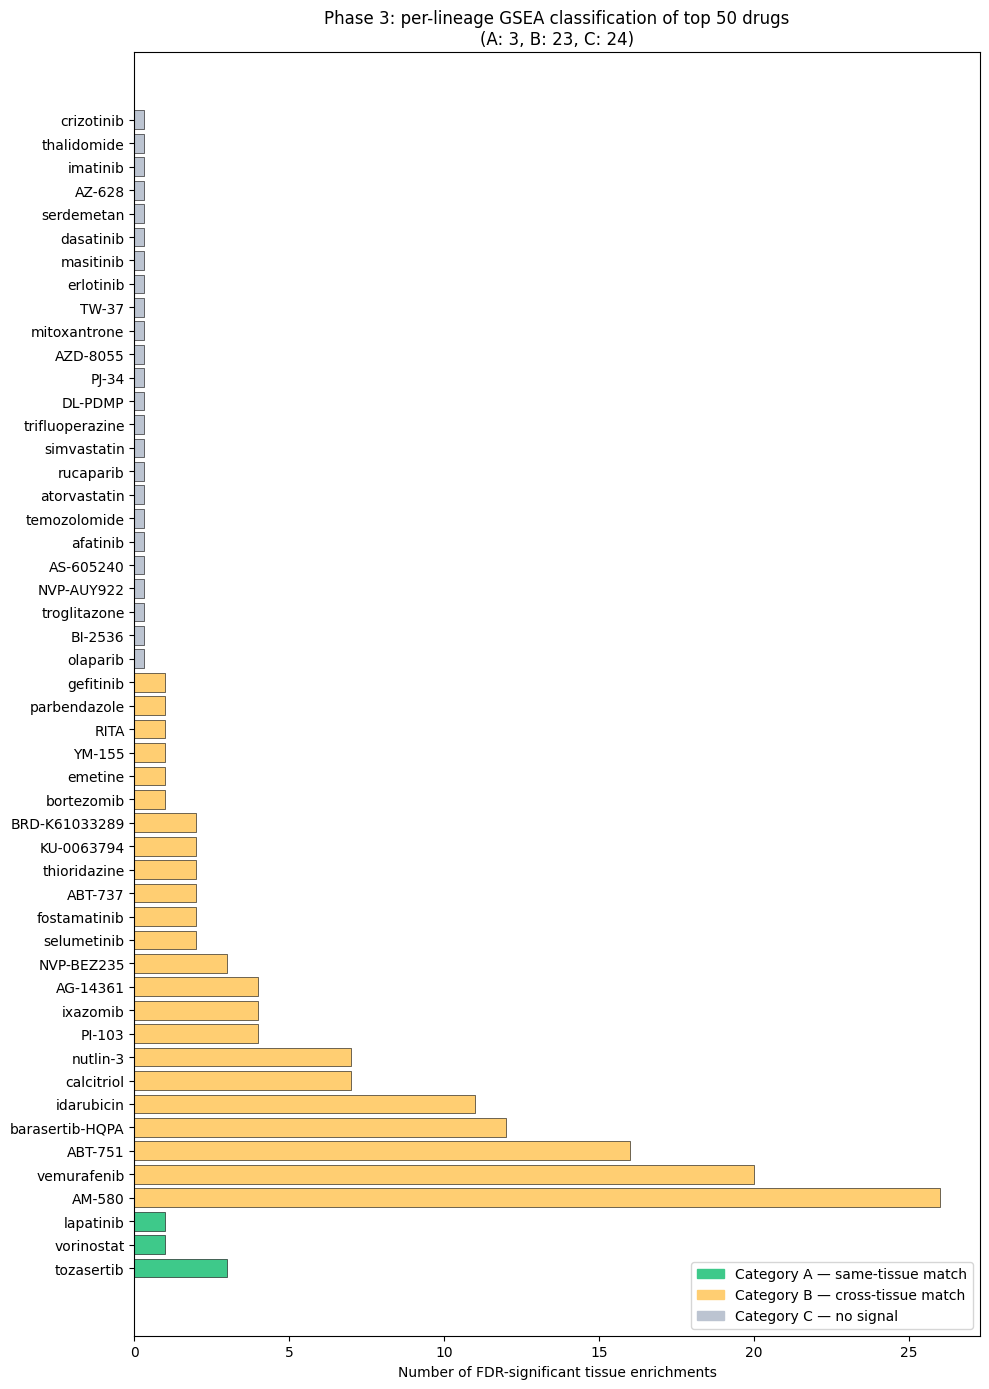


✓ Saved: phase3_classification_chart.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Prep data
plot_df = results_df.sort_values(['category', 'cat_a_evidence_count',
                                    'cat_b_evidence_count'],
                                   ascending=[True, False, False])

# Color by category
cat_colors = {'A': '#3ec98a', 'B': '#ffce72', 'C': '#bcc4d1'}
colors = [cat_colors[c] for c in plot_df['category']]

# Build bar values: A drugs use A_evidence, B drugs use B_evidence, C drugs = 0
bar_vals = []
for _, row in plot_df.iterrows():
    if row['category'] == 'A':
        bar_vals.append(row['cat_a_evidence_count'])
    elif row['category'] == 'B':
        bar_vals.append(row['cat_b_evidence_count'])
    else:
        bar_vals.append(0.3)  # tiny bar for visibility

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(plot_df['drug'], bar_vals, color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlabel('Number of FDR-significant tissue enrichments')
ax.set_title('Phase 3: per-lineage GSEA classification of top 50 drugs\n'
             f'(A: {sum(plot_df["category"]=="A")}, '
             f'B: {sum(plot_df["category"]=="B")}, '
             f'C: {sum(plot_df["category"]=="C")})')

# Legend
patches = [
    mpatches.Patch(color='#3ec98a', label='Category A — same-tissue match'),
    mpatches.Patch(color='#ffce72', label='Category B — cross-tissue match'),
    mpatches.Patch(color='#bcc4d1', label='Category C — no signal'),
]
ax.legend(handles=patches, loc='lower right')

plt.tight_layout()
plt.savefig('phase3_classification_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: phase3_classification_chart.png")

## Step 19: Backup Phase 3 outputs to Google Drive

Save all results to Drive so the Colab session ending doesn't lose them.

Files to back up:
- `phase3_classification_final.csv` — full A/B/C table
- `phase3_category_A_drugs.csv` — Cat A detail
- `phase3_category_B_drugs.csv` — Cat B detail
- `phase3_classification_chart.png` — the visualization
- `phase3_classification_checkpoint.csv` — backup

In [25]:
import shutil

# Create Phase 3 folder in Drive
phase3_folder = '/content/drive/MyDrive/Project59_Phase3'
os.makedirs(phase3_folder, exist_ok=True)

files_to_backup = [
    'phase3_classification_final.csv',
    'phase3_category_A_drugs.csv',
    'phase3_category_B_drugs.csv',
    'phase3_classification_chart.png',
    'phase3_classification_checkpoint.csv',
]

print("Backing up Phase 3 outputs to Drive...\n")
for f in files_to_backup:
    if os.path.exists(f):
        target = os.path.join(phase3_folder, f)
        shutil.copy(f, target)
        size = os.path.getsize(f) / 1024
        print(f"  ✓ {f}  ({size:.1f} KB)")
    else:
        print(f"  ✗ {f}  NOT FOUND")

print(f"\n✓ All saved to: {phase3_folder}")
print(f"\nDrive contents:")
!ls -lh "{phase3_folder}/"

Backing up Phase 3 outputs to Drive...

  ✓ phase3_classification_final.csv  (7.1 KB)
  ✓ phase3_category_A_drugs.csv  (1.4 KB)
  ✓ phase3_category_B_drugs.csv  (5.2 KB)
  ✓ phase3_classification_chart.png  (173.2 KB)
  ✓ phase3_classification_checkpoint.csv  (7.1 KB)

✓ All saved to: /content/drive/MyDrive/Project59_Phase3

Drive contents:
total 196K
-rw------- 1 root root 1.4K Jun  7 18:20 phase3_category_A_drugs.csv
-rw------- 1 root root 5.2K Jun  7 18:20 phase3_category_B_drugs.csv
-rw------- 1 root root 174K Jun  7 18:20 phase3_classification_chart.png
-rw------- 1 root root 7.1K Jun  7 18:20 phase3_classification_checkpoint.csv
-rw------- 1 root root 7.1K Jun  7 18:20 phase3_classification_final.csv


In [27]:
from google.colab import files
files.download('/content/drive/MyDrive/Project59_Phase3/phase3_classification_final.csv')
files.download('/content/drive/MyDrive/Project59_Phase3/phase3_category_A_drugs.csv')
files.download('/content/drive/MyDrive/Project59_Phase3/phase3_category_B_drugs.csv')
files.download('/content/drive/MyDrive/Project59_Phase3/phase3_classification_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Phase 4 — Fix Marouen's feedback

Marouen pointed out two important things:

1. **Build male and female libraries separately** per tissue.
   GTEx sbgenes file has `effsize` column:
   - effsize > 0 → gene is male-biased in that tissue
   - effsize < 0 → gene is female-biased

2. **Direction interpretation**: sex bias direction should come from
   which library (male or female) is enriched — NOT from NES sign.
   In Phase 3 I read NES > 0 as "male-biased" which was wrong.

Fix below: split sb_library into male and female sets per tissue.

In [28]:
# Split GTEx sb-genes into MALE and FEMALE libraries per tissue
# Based on the sign of effsize:
#   effsize > 0  →  gene is biased toward MALES in that tissue
#   effsize < 0  →  gene is biased toward FEMALES in that tissue

import pandas as pd
sbg = pd.read_csv('GTEx_Analysis_v8_sbgenes/signif.sbgenes.txt', sep='\t')

# Reload the raw sbgenes table (we already have `sbg` from Phase 3)
print(f"Total sbgenes rows: {len(sbg):,}")
print(f"Effsize distribution:")
print(f"  positive (male-biased):   {(sbg['effsize'] > 0).sum():,}")
print(f"  negative (female-biased): {(sbg['effsize'] < 0).sum():,}")
print(f"  zero:                     {(sbg['effsize'] == 0).sum():,}")

# Clean version-suffix from gene IDs (ENSG...10 → ENSG...)
sbg['gene_clean'] = sbg['gene'].apply(lambda g: g.split('.')[0])

# Build the two libraries
male_lib = {}
female_lib = {}

for tissue in sbg['tissue'].unique():
    tissue_rows = sbg[sbg['tissue'] == tissue]
    male_genes = set(tissue_rows[tissue_rows['effsize'] > 0]['gene_clean'])
    female_genes = set(tissue_rows[tissue_rows['effsize'] < 0]['gene_clean'])
    male_lib[f"Male_{tissue}"] = male_genes
    female_lib[f"Female_{tissue}"] = female_genes

# Combined for GSEA — 88 sets total (44 tissues × 2 sexes)
sb_libs_split = {**male_lib, **female_lib}

print(f"\nTotal sets in split library: {len(sb_libs_split)}")
print(f"  Male libraries:   {len(male_lib)}")
print(f"  Female libraries: {len(female_lib)}")

# Quick sanity check — Lung
print(f"\n--- Lung sanity check ---")
print(f"Male_Lung:   {len(sb_libs_split['Male_Lung'])} genes")
print(f"Female_Lung: {len(sb_libs_split['Female_Lung'])} genes")
print(f"Total Lung sb-genes (Phase 3): {len(sb_library_sets['Lung'])}")
print(f"Sum check: Male + Female = {len(sb_libs_split['Male_Lung']) + len(sb_libs_split['Female_Lung'])}")

Total sbgenes rows: 104,864
Effsize distribution:
  positive (male-biased):   52,851
  negative (female-biased): 52,013
  zero:                     0

Total sets in split library: 88
  Male libraries:   44
  Female libraries: 44

--- Lung sanity check ---
Male_Lung:   1098 genes
Female_Lung: 1010 genes
Total Lung sb-genes (Phase 3): 2108
Sum check: Male + Female = 2108


In [29]:
# Quick verification — show actual genes in male vs female Lung library
print("=" * 60)
print("Lung — Top 10 MALE-biased genes (highest +effsize)")
print("=" * 60)
lung_male = sbg[(sbg['tissue']=='Lung') & (sbg['effsize']>0)].sort_values('effsize', ascending=False)
print(lung_male[['gene','effsize']].head(10).to_string(index=False))

print("\n" + "=" * 60)
print("Lung — Top 10 FEMALE-biased genes (most negative effsize)")
print("=" * 60)
lung_female = sbg[(sbg['tissue']=='Lung') & (sbg['effsize']<0)].sort_values('effsize')
print(lung_female[['gene','effsize']].head(10).to_string(index=False))

# Save split libraries to Drive for next session
import pickle, os
os.makedirs('/content/drive/MyDrive/Project59_Phase4', exist_ok=True)
with open('/content/drive/MyDrive/Project59_Phase4/sb_libs_split.pkl', 'wb') as f:
    pickle.dump(sb_libs_split, f)
print("\n✓ Saved sb_libs_split.pkl to Drive (for next session)")

Lung — Top 10 MALE-biased genes (highest +effsize)
              gene   effsize
ENSG00000229807.10 10.068865
 ENSG00000261600.1  1.028811
 ENSG00000234449.2  0.806534
ENSG00000130021.13  0.739852
ENSG00000196433.12  0.690347
ENSG00000184368.15  0.669291
ENSG00000011201.11  0.660495
ENSG00000147050.14  0.638654
ENSG00000173809.17  0.619046
 ENSG00000180574.3  0.595851

Lung — Top 10 FEMALE-biased genes (most negative effsize)
              gene   effsize
 ENSG00000253967.1 -1.576386
 ENSG00000205611.4 -1.564481
ENSG00000132204.13 -1.176703
 ENSG00000203907.9 -1.026333
 ENSG00000080007.7 -0.983922
 ENSG00000282935.1 -0.846661
 ENSG00000255346.9 -0.800527
 ENSG00000258484.3 -0.712267
 ENSG00000237438.7 -0.679017
 ENSG00000260802.1 -0.611608

✓ Saved sb_libs_split.pkl to Drive (for next session)


In [30]:
# CORRECTION: GTEx convention is positive effsize = FEMALE-biased
# Swap the labels we built earlier

# Rebuild with correct labels
female_lib = {}
male_lib = {}

for tissue in sbg['tissue'].unique():
    tissue_rows = sbg[sbg['tissue'] == tissue]
    # POSITIVE effsize = higher in females
    female_genes = set(tissue_rows[tissue_rows['effsize'] > 0]['gene_clean'])
    # NEGATIVE effsize = higher in males
    male_genes = set(tissue_rows[tissue_rows['effsize'] < 0]['gene_clean'])
    female_lib[f"Female_{tissue}"] = female_genes
    male_lib[f"Male_{tissue}"] = male_genes

sb_libs_split = {**female_lib, **male_lib}

# Verify with XIST
xist = 'ENSG00000229807'
ddx43 = 'ENSG00000080007'

print("Sanity check — well-known sex-biased genes:")
print(f"  XIST ({xist}) — known FEMALE-biased gene:")
print(f"    In Female_Lung? {xist in sb_libs_split['Female_Lung']}  (should be True)")
print(f"    In Male_Lung?   {xist in sb_libs_split['Male_Lung']}    (should be False)")

print(f"\n  DDX43 ({ddx43}) — testis-expressed, MALE-biased:")
print(f"    In Female_Lung? {ddx43 in sb_libs_split['Female_Lung']}  (should be False)")
print(f"    In Male_Lung?   {ddx43 in sb_libs_split['Male_Lung']}    (should be True)")

# Save corrected version to Drive
import pickle
with open('/content/drive/MyDrive/Project59_Phase4/sb_libs_split.pkl', 'wb') as f:
    pickle.dump(sb_libs_split, f)
print("\n✓ Corrected libraries saved to Drive")

Sanity check — well-known sex-biased genes:
  XIST (ENSG00000229807) — known FEMALE-biased gene:
    In Female_Lung? True  (should be True)
    In Male_Lung?   False    (should be False)

  DDX43 (ENSG00000080007) — testis-expressed, MALE-biased:
    In Female_Lung? False  (should be False)
    In Male_Lung?   True    (should be True)

✓ Corrected libraries saved to Drive


In [32]:
# Phase 4 Step 2 — Reload all metadata
import pandas as pd
import numpy as np
import os, time, pickle
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import gseapy
import warnings
warnings.filterwarnings('ignore')

# Download CMAP small metadata if not present
for url, name in [
    ('https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/cellinfo_beta.txt', 'cellinfo_beta.txt'),
    ('https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/geneinfo_beta.txt', 'geneinfo_beta.txt'),
]:
    if not os.path.exists(name):
        !curl -O {url}

if not os.path.exists('siginfo_beta.txt'):
    print("Downloading siginfo (444 MB, ~15 sec)...")
    !curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/siginfo_beta.txt

# Load
cell = pd.read_csv('cellinfo_beta.txt', sep='\t')
genes_info = pd.read_csv('geneinfo_beta.txt', sep='\t')
print("Loading siginfo (1.2M rows)...")
sig = pd.read_csv('siginfo_beta.txt', sep='\t', low_memory=False)

# Merge & filter
cell_small = cell[['cell_iname', 'donor_sex', 'cell_type', 'cell_lineage']]
sig = sig.merge(cell_small, on='cell_iname', how='left')
sig_known = sig[(sig['pert_type']=='trt_cp') & (sig['donor_sex'].isin(['M','F']))].copy()
print(f"sig_known: {sig_known.shape}")

# Build top 50 drugs
drug_summary = sig_known.pivot_table(
    index='cmap_name', columns='donor_sex',
    values='cell_iname', aggfunc='nunique', fill_value=0
)
drug_summary['total'] = drug_summary['F'] + drug_summary['M']
good_drugs = drug_summary[(drug_summary['M']>=5) & (drug_summary['F']>=5)].sort_values('total', ascending=False)
top50_drugs = good_drugs.head(50)
top50_names = top50_drugs.index.tolist()

# CMAP↔GTEx mapping
cmap_to_gtex = {
    'lung': ['Lung'],
    'breast': ['Breast_Mammary_Tissue'],
    'skin': ['Skin_Sun_Exposed_Lower_leg', 'Skin_Not_Sun_Exposed_Suprapubic'],
    'liver': ['Liver'],
    'kidney': ['Kidney_Cortex'],
    'stomach': ['Stomach'],
    'pancreas': ['Pancreas'],
    'large_intestine': ['Colon_Sigmoid', 'Colon_Transverse'],
    'haematopoietic_and_lymphoid_tissue': ['Whole_Blood', 'Spleen', 'Cells_EBV.transformed_lymphocytes'],
    'central_nervous_system': [t for t in sbg['tissue'].unique() if t.startswith('Brain_')],
}

# Universe + translator
universe_ensg = set(genes_info['ensembl_id'].dropna().unique())
gid_to_ensg = dict(zip(genes_info['gene_id'].astype(str), genes_info['ensembl_id']))

print(f"\n✓ All metadata reloaded")
print(f"  top50_drugs: {len(top50_names)}")
print(f"  universe_ensg: {len(universe_ensg):,}")
print(f"  sb_libs_split: {len(sb_libs_split)} sets")
print(f"  cmap_to_gtex: {len(cmap_to_gtex)} lineages mapped")

Loading siginfo (1.2M rows)...
sig_known: (596117, 40)

✓ All metadata reloaded
  top50_drugs: 50
  universe_ensg: 12,276
  sb_libs_split: 88 sets
  cmap_to_gtex: 10 lineages mapped


In [34]:
# Phase 4 Step 3 — Download gctx + verify lapatinib signatures
!pip install cmapPy --quiet
from cmapPy.pandasGEXpress.parse import parse

gctx_file = 'level5_beta_trt_cp_n720216x12328.gctx'

if not os.path.exists(gctx_file):
    print("Downloading gctx (33 GB)... ~15 minutes")
    !curl -O https://cmapreg.s3.amazonaws.com/galenAI/{gctx_file}

# Read column metadata (fast, ~10 seconds)
print("\nReading column labels...")
col_meta = parse(gctx_file, col_meta_only=True)
gctx_sigs = set(col_meta.index)
print(f"✓ Total signatures in gctx: {len(gctx_sigs):,}")

# Verify lapatinib signatures present
lap_sigs = sig_known[sig_known['cmap_name']=='lapatinib']
lap_valid = [s for s in lap_sigs['sig_id'] if s in gctx_sigs]
print(f"\nLapatinib check:")
print(f"  Total lapatinib experiments: {len(lap_sigs)}")
print(f"  Valid in gctx file: {len(lap_valid)}")
print(f"  M/F split: {lap_sigs[lap_sigs['donor_sex']=='M'].shape[0]} M / {lap_sigs[lap_sigs['donor_sex']=='F'].shape[0]} F")
print(f"  Lineages: {sorted(lap_sigs['cell_lineage'].dropna().unique())}")


Reading column labels...
✓ Total signatures in gctx: 720,216

Lapatinib check:
  Total lapatinib experiments: 722
  Valid in gctx file: 722
  M/F split: 278 M / 444 F
  Lineages: ['bone', 'breast', 'central_nervous_system', 'cervix', 'endometrium', 'haematopoietic_and_lymphoid_tissue', 'kidney', 'large_intestine', 'liver', 'lung', 'ovary', 'pancreas', 'placenta', 'prostate', 'skin', 'soft_tissue', 'stomach', 'upper_aerodigestive_tract', 'urinary_tract']


In [35]:
# Phase 4 Step 4 — New analyze function (Marouen's exact recipe)
def analyze_drug_lineage_v4(drug_name, lineage, verbose=False):
    """
    Phase 4: Per (drug, lineage) GSEA against split male/female libraries.
    - Uses z-scores DIRECTLY (no Mann-Whitney)
    - Mean z-score per gene across all signatures of (drug, lineage)
    - GSEA against 88 split sets
    - Direction comes from library name (Male_X or Female_X)
    """
    sigs = sig_known[
        (sig_known['cmap_name'] == drug_name) &
        (sig_known['cell_lineage'] == lineage)
    ]
    if len(sigs) < 10:
        return None

    valid_ids = [s for s in sigs['sig_id'] if s in gctx_sigs]
    if len(valid_ids) < 10:
        return None

    # Pull z-scores
    data = parse(gctx_file, cid=valid_ids)
    expr = data.data_df  # 12,328 genes × N sigs

    # Mean z-score per gene across signatures (collapse sigs to gene-level summary)
    mean_z = expr.mean(axis=1)
    mean_z.index = mean_z.index.astype(str)

    # Entrez → Ensembl translation
    ensg_scores = {}
    for gid, z in mean_z.items():
        ensg = gid_to_ensg.get(gid)
        if ensg and not pd.isna(ensg):
            ensg_scores[ensg] = z
    if not ensg_scores:
        return None

    # Sort by z-score (descending) — this IS the ranked list
    ranked = pd.Series(ensg_scores).sort_values(ascending=False)

    # Optional info: how many genes pass |z| > 2
    n_strong = (ranked.abs() > 2.0).sum()
    if verbose:
        print(f"  {drug_name} × {lineage}: {len(valid_ids)} sigs, {n_strong} genes |z|>2")

    # Run GSEA against 88 split libraries
    try:
        result = gseapy.prerank(
            rnk=ranked.reset_index(),
            gene_sets=sb_libs_split,
            permutation_num=200,   # 200 for speed; can bump to 1000 later
            min_size=15,
            max_size=10000,
            no_plot=True,
            verbose=False,
            seed=42
        )
        gsea_df = result.res2d
    except Exception as e:
        if verbose:
            print(f"  GSEA error: {e}")
        return None

    return {
        'drug': drug_name,
        'lineage': lineage,
        'n_sigs': len(valid_ids),
        'n_M': sigs[sigs['donor_sex']=='M']['cell_iname'].nunique(),
        'n_F': sigs[sigs['donor_sex']=='F']['cell_iname'].nunique(),
        'n_strong_z': int(n_strong),
        'gsea': gsea_df
    }


def classify_drug_lineage(result, cmap_to_gtex):
    """
    Convert GSEA result to A/B/C classification + sex direction.
    Each significant library (FDR < 0.05) → one row of classification.
    """
    if result is None:
        return []

    drug = result['drug']
    lineage = result['lineage']
    home_tissues = set(cmap_to_gtex.get(lineage, []))

    gsea = result['gsea']
    sig_rows = gsea[gsea['FDR q-val'] < 0.05]

    classifications = []
    for _, row in sig_rows.iterrows():
        term = row['Term']  # e.g., 'Female_Lung' or 'Male_Brain_Cortex'

        # Parse direction (sex) and tissue from library name
        if term.startswith('Female_'):
            sex_direction = 'Female'
            tissue = term.replace('Female_', '')
        elif term.startswith('Male_'):
            sex_direction = 'Male'
            tissue = term.replace('Male_', '')
        else:
            continue

        # Classify A/B/C
        if tissue in home_tissues:
            category = 'A'  # same-tissue match
        else:
            category = 'B'  # cross-tissue

        classifications.append({
            'drug': drug,
            'lineage': lineage,
            'tissue': tissue,
            'sex_direction': sex_direction,
            'category': category,
            'NES': row['NES'],
            'FDR': row['FDR q-val'],
            'n_sigs': result['n_sigs']
        })

    # If no significant libraries → Cat C
    if not classifications:
        classifications.append({
            'drug': drug, 'lineage': lineage, 'tissue': None,
            'sex_direction': None, 'category': 'C',
            'NES': None, 'FDR': None, 'n_sigs': result['n_sigs']
        })

    return classifications


print("✓ Phase 4 analyze functions defined")
print("  - analyze_drug_lineage_v4(drug, lineage)")
print("  - classify_drug_lineage(result, cmap_to_gtex)")

✓ Phase 4 analyze functions defined
  - analyze_drug_lineage_v4(drug, lineage)
  - classify_drug_lineage(result, cmap_to_gtex)


In [36]:
# Phase 4 Step 5 — Lapatinib × lung test (Marouen's bug check)
import time

print("Testing lapatinib × lung (Marouen's query)...")
t0 = time.time()
result = analyze_drug_lineage_v4('lapatinib', 'lung', verbose=True)
print(f"Done in {time.time()-t0:.0f}s\n")

if result is None:
    print("✗ Not enough data")
else:
    # Show top significant libraries
    sig_libs = result['gsea'][result['gsea']['FDR q-val'] < 0.05].sort_values('FDR q-val')
    print(f"FDR-significant libraries: {len(sig_libs)}\n")
    if len(sig_libs) > 0:
        print(sig_libs[['Term','NES','FDR q-val']].head(10).to_string(index=False))

    # Classify
    classifications = classify_drug_lineage(result, cmap_to_gtex)
    print(f"\n--- Classification rows for lapatinib × lung ---")
    for c in classifications[:10]:
        print(f"  {c['category']} | {c['sex_direction']} | {c['tissue']} | NES={c['NES']:.3f} | FDR={c['FDR']:.4f}" if c['category']!='C' else f"  C | no significant signal")

Testing lapatinib × lung (Marouen's query)...


2026-06-07 18:34:29,044 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  lapatinib × lung: 105 sigs, 0 genes |z|>2
Done in 9s

FDR-significant libraries: 8

                                 Term       NES  FDR q-val
          Female_Minor_Salivary_Gland -1.585311   0.005000
         Female_Breast_Mammary_Tissue -1.530952   0.005000
                 Female_Colon_Sigmoid -1.480881   0.006356
              Female_Esophagus_Mucosa -1.504028   0.007062
Female_Small_Intestine_Terminal_Ileum -1.455822   0.007627
              Female_Colon_Transverse -1.427279   0.012712
                       Female_Stomach -1.349133   0.037076
                       Male_Pituitary -1.360918   0.037530

--- Classification rows for lapatinib × lung ---
  B | Female | Minor_Salivary_Gland | NES=-1.585 | FDR=0.0050
  B | Female | Breast_Mammary_Tissue | NES=-1.531 | FDR=0.0050
  B | Female | Esophagus_Mucosa | NES=-1.504 | FDR=0.0071
  B | Female | Colon_Sigmoid | NES=-1.481 | FDR=0.0064
  B | Female | Small_Intestine_Terminal_Ileum | NES=-1.456 | FDR=0.0076
  B | Female | Colon_Tr

In [37]:
# Phase 4 Step 6 — Run full pipeline on all 50 drugs × all their lineages
import time

all_classifications = []
start = time.time()
done_count = 0

for i, drug_name in enumerate(top50_names, 1):
    drug_sigs = sig_known[sig_known['cmap_name']==drug_name]
    drug_lineages = set(drug_sigs['cell_lineage'].dropna().unique()) - {'unknown'}

    for lineage in drug_lineages:
        t0 = time.time()
        try:
            result = analyze_drug_lineage_v4(drug_name, lineage, verbose=False)
        except Exception as e:
            continue

        if result is None:
            continue

        classifications = classify_drug_lineage(result, cmap_to_gtex)
        all_classifications.extend(classifications)
        done_count += 1

        elapsed = time.time() - t0
        n_sig = len([c for c in classifications if c['category']!='C'])
        print(f"[{i:2}/50] {drug_name:30} × {lineage:30} → {elapsed:>3.0f}s · {n_sig} significant rows")

    # Checkpoint every 5 drugs
    if i % 5 == 0:
        cls_df = pd.DataFrame(all_classifications)
        cls_df.to_csv('phase4_classifications_checkpoint.csv', index=False)
        print(f"  ↳ Checkpoint · Total elapsed: {(time.time()-start)/60:.1f} min · {done_count} (drug,lineage) processed")

# Final save
cls_df = pd.DataFrame(all_classifications)
cls_df.to_csv('phase4_classifications_final.csv', index=False)

# Save to Drive
import shutil
shutil.copy('phase4_classifications_final.csv', '/content/drive/MyDrive/Project59_Phase4/')

print(f"\n=== DONE === Total: {(time.time()-start)/60:.1f} min · {len(all_classifications)} classification rows")
print(f"\nCategory breakdown:")
print(cls_df['category'].value_counts())
print(f"\nDirection breakdown (excluding C):")
print(cls_df[cls_df['category']!='C']['sex_direction'].value_counts())

2026-06-07 18:36:11,922 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[ 1/50] selumetinib                    × large_intestine                →   6s · 48 significant rows


2026-06-07 18:36:17,727 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[ 1/50] selumetinib                    × cervix                         →   4s · 55 significant rows


2026-06-07 18:36:22,208 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

[50/50] crizotinib                     × ovary                          →   6s · 36 significant rows
[50/50] crizotinib                     × pancreas                       →   5s · 16 significant rows


2026-06-07 19:28:14,985 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[50/50] crizotinib                     × kidney                         →   4s · 2 significant rows
[50/50] crizotinib                     × bone                           →   6s · 1 significant rows


2026-06-07 19:28:25,276 [WARNING] Duplicated values found in preranked stats: 0.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[50/50] crizotinib                     × placenta                       →   4s · 1 significant rows
  ↳ Checkpoint · Total elapsed: 52.3 min · 603 (drug,lineage) processed

=== DONE === Total: 52.3 min · 9260 classification rows

Category breakdown:
category
B    8942
A     237
C      81
Name: count, dtype: int64

Direction breakdown (excluding C):
sex_direction
Female    5104
Male      4075
Name: count, dtype: int64


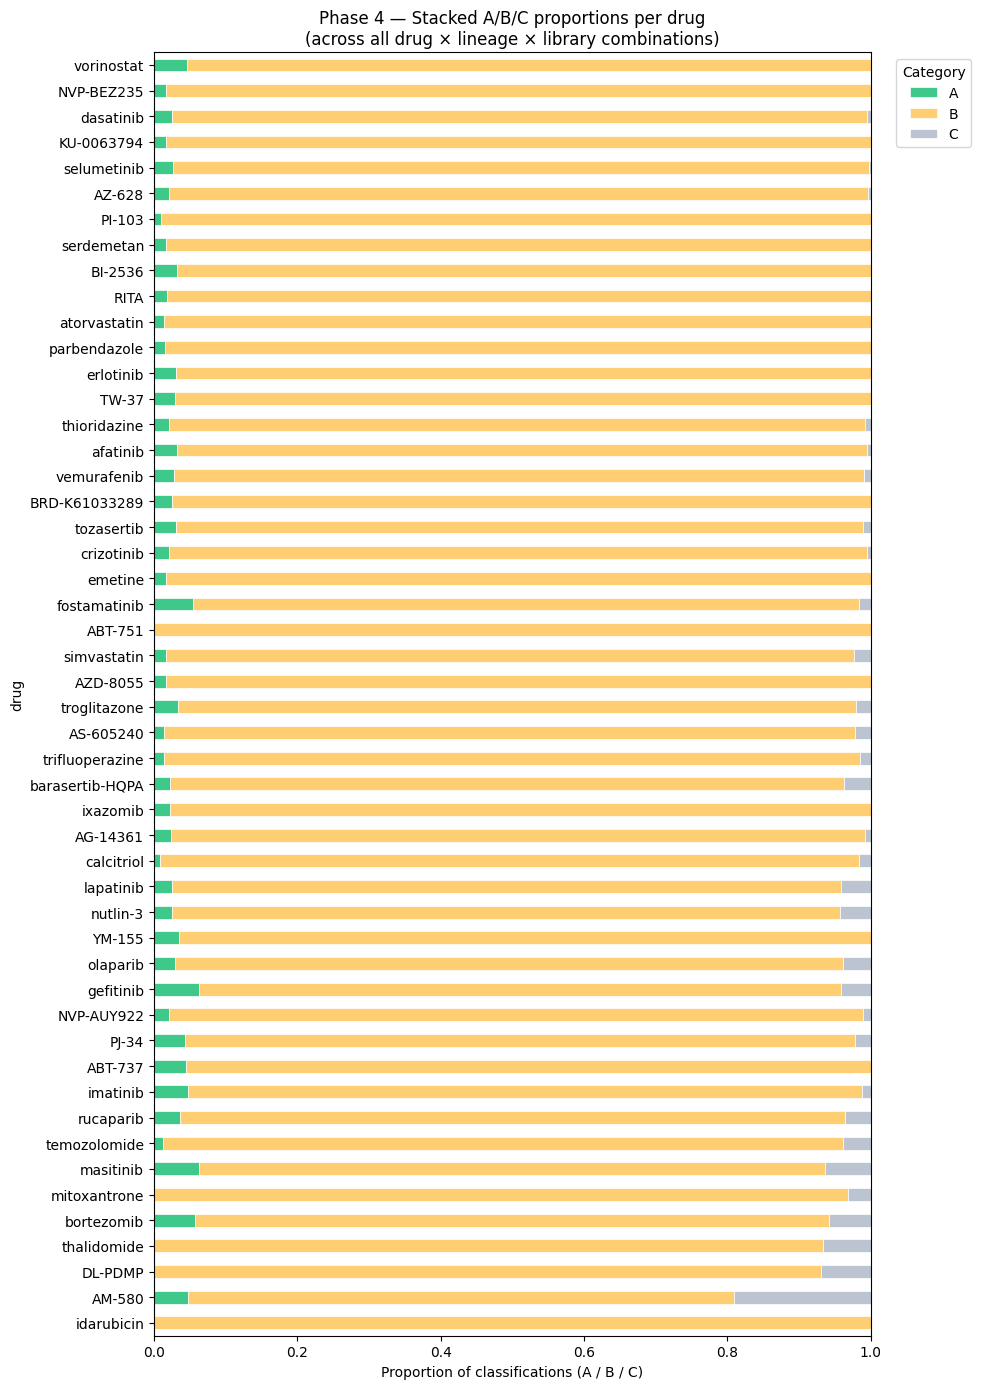


--- Sex direction breakdown (excluding C) ---
Total significant classifications: 9,179
  Female direction: 5,104
  Male direction:   4,075

✓ Files saved to Drive: /content/drive/MyDrive/Project59_Phase4/


In [38]:
# Phase 4 Step 7 — Stacked bar chart per drug (Marouen's exact request)
import matplotlib.pyplot as plt

# Reload classifications (in case kernel restarted)
cls_df = pd.read_csv('phase4_classifications_final.csv')

# For each drug, get A/B/C counts across all (drug, lineage, library) classifications
drug_props = cls_df.groupby(['drug','category']).size().unstack(fill_value=0)
# Ensure A, B, C columns exist
for cat in ['A','B','C']:
    if cat not in drug_props.columns:
        drug_props[cat] = 0
drug_props = drug_props[['A','B','C']]

# Sort by total count
drug_props['total'] = drug_props.sum(axis=1)
drug_props = drug_props.sort_values('total', ascending=True)

# Convert to proportions
prop = drug_props[['A','B','C']].div(drug_props['total'], axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 14))
prop.plot(kind='barh', stacked=True, ax=ax,
          color=['#3ec98a','#ffce72','#bcc4d1'], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Proportion of classifications (A / B / C)')
ax.set_xlim(0, 1)
ax.set_title('Phase 4 — Stacked A/B/C proportions per drug\n'
             '(across all drug × lineage × library combinations)')
ax.legend(title='Category', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig('phase4_stacked_per_drug.png', dpi=150, bbox_inches='tight')
plt.show()

# Also: sex direction breakdown
print("\n--- Sex direction breakdown (excluding C) ---")
non_c = cls_df[cls_df['category']!='C']
print(f"Total significant classifications: {len(non_c):,}")
print(f"  Female direction: {(non_c['sex_direction']=='Female').sum():,}")
print(f"  Male direction:   {(non_c['sex_direction']=='Male').sum():,}")

# Save to Drive
import shutil
shutil.copy('phase4_stacked_per_drug.png', '/content/drive/MyDrive/Project59_Phase4/')
shutil.copy('phase4_classifications_final.csv', '/content/drive/MyDrive/Project59_Phase4/')
print("\n✓ Files saved to Drive: /content/drive/MyDrive/Project59_Phase4/")

In [39]:
# Phase 4 final save — confirm everything is on Drive
import shutil, os
os.makedirs('/content/drive/MyDrive/Project59_Phase4', exist_ok=True)

files_to_save = [
    'phase4_classifications_final.csv',
    'phase4_stacked_per_drug.png',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, '/content/drive/MyDrive/Project59_Phase4/')
        print(f"✓ Saved: {f}")
    else:
        print(f"✗ Missing: {f}")

print("\n📁 Drive folder contents:")
!ls -lh /content/drive/MyDrive/Project59_Phase4/

✓ Saved: phase4_classifications_final.csv
✓ Saved: phase4_stacked_per_drug.png

📁 Drive folder contents:
total 2.8M
-rw------- 1 root root 767K Jun  7 19:31 phase4_classifications_final.csv
-rw------- 1 root root 170K Jun  7 19:31 phase4_stacked_per_drug.png
-rw------- 1 root root 1.9M Jun  7 18:24 sb_libs_split.pkl


In [40]:
# CRITICAL CHECK — verify GTEx sign convention using Y-chromosome genes
# Y-genes can ONLY be expressed in males (XY karyotype)
# If positive effsize = males → Y-genes will be POSITIVE
# If positive effsize = females → Y-genes will be NEGATIVE

# Known Y-chromosome genes
y_genes = {
    'RPS4Y1': 'ENSG00000129824',
    'DDX3Y':  'ENSG00000067048',
    'USP9Y':  'ENSG00000114374',
    'UTY':    'ENSG00000183878',
    'EIF1AY': 'ENSG00000198692',
    'KDM5D':  'ENSG00000012817',
}

# Known X-escape FEMALE-biased genes (should be opposite sign)
x_female_genes = {
    'XIST':   'ENSG00000229807',
    'KDM6A':  'ENSG00000147050',
    'TSIX':   'ENSG00000270641',
    'EIF1AX': 'ENSG00000173674',
}

# Clean sbg gene IDs for matching
sbg['gene_root'] = sbg['gene'].apply(lambda g: g.split('.')[0])

print("=" * 70)
print("Y-chromosome genes (MUST be male-biased)")
print("=" * 70)
for sym, ensg in y_genes.items():
    rows = sbg[(sbg['gene_root']==ensg) & (sbg['tissue']=='Lung')]
    if len(rows) > 0:
        eff = rows['effsize'].iloc[0]
        sign = "+ POSITIVE" if eff > 0 else "− NEGATIVE"
        print(f"  {sym:10} ({ensg}) → effsize = {eff:+.3f}  [{sign}]")
    else:
        # Check in any tissue
        any_rows = sbg[sbg['gene_root']==ensg]
        if len(any_rows) > 0:
            row = any_rows.iloc[0]
            eff = row['effsize']
            sign = "+ POSITIVE" if eff > 0 else "− NEGATIVE"
            print(f"  {sym:10} ({ensg}) → effsize = {eff:+.3f}  [{sign}]  (in {row['tissue']})")
        else:
            print(f"  {sym:10} ({ensg}) → not in significant sb-genes")

print("\n" + "=" * 70)
print("X-escape female-biased genes (MUST be female-biased — opposite sign)")
print("=" * 70)
for sym, ensg in x_female_genes.items():
    rows = sbg[(sbg['gene_root']==ensg) & (sbg['tissue']=='Lung')]
    if len(rows) > 0:
        eff = rows['effsize'].iloc[0]
        sign = "+ POSITIVE" if eff > 0 else "− NEGATIVE"
        print(f"  {sym:10} ({ensg}) → effsize = {eff:+.3f}  [{sign}]")
    else:
        any_rows = sbg[sbg['gene_root']==ensg]
        if len(any_rows) > 0:
            row = any_rows.iloc[0]
            eff = row['effsize']
            sign = "+ POSITIVE" if eff > 0 else "− NEGATIVE"
            print(f"  {sym:10} ({ensg}) → effsize = {eff:+.3f}  [{sign}]  (in {row['tissue']})")
        else:
            print(f"  {sym:10} ({ensg}) → not in significant sb-genes")

print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)
print("""
If Y-genes are POSITIVE and X-female genes are NEGATIVE
  → POSITIVE effsize = MALE-biased (Marouen is right)
  → We need to SWAP our libraries (Female_X ↔ Male_X)

If Y-genes are NEGATIVE and X-female genes are POSITIVE
  → POSITIVE effsize = FEMALE-biased (our current setup is right)
  → No changes needed
""")

Y-chromosome genes (MUST be male-biased)
  RPS4Y1     (ENSG00000129824) → not in significant sb-genes
  DDX3Y      (ENSG00000067048) → not in significant sb-genes
  USP9Y      (ENSG00000114374) → not in significant sb-genes
  UTY        (ENSG00000183878) → not in significant sb-genes
  EIF1AY     (ENSG00000198692) → not in significant sb-genes
  KDM5D      (ENSG00000012817) → not in significant sb-genes

X-escape female-biased genes (MUST be female-biased — opposite sign)
  XIST       (ENSG00000229807) → effsize = +10.069  [+ POSITIVE]
  KDM6A      (ENSG00000147050) → effsize = +0.639  [+ POSITIVE]
  TSIX       (ENSG00000270641) → effsize = +7.480  [+ POSITIVE]  (in Heart_Atrial_Appendage)
  EIF1AX     (ENSG00000173674) → effsize = +0.483  [+ POSITIVE]

VERDICT

If Y-genes are POSITIVE and X-female genes are NEGATIVE
  → POSITIVE effsize = MALE-biased (Marouen is right)
  → We need to SWAP our libraries (Female_X ↔ Male_X)

If Y-genes are NEGATIVE and X-female genes are POSITIVE
  → PO